# Comparative Analysis of Cardiovascular Machine Learning Models

## Project Overview

This notebook brings together the findings from three independent cardiovascular prediction tasks:

1. Ten-year coronary heart disease risk prediction using the Framingham dataset.
2. Heart disease detection using the Heart Disease dataset.
3. Adverse heart failure outcome prediction using the Heart Failure dataset.

The datasets are not merged into a single training table because their target variables represent different clinical outcomes. Instead, they are jointly analysed through dataset comparison, preprocessing comparison, model evaluation and integrated deployment within one Flask application.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# Load the Three Cardiovascular Datasets
# ============================================================

framingham = pd.read_csv("/content/framingham.csv")
heart = pd.read_csv("/content/heart.csv")
heart_failure = pd.read_csv("/content/heart_failure.csv")

print("Framingham shape   :", framingham.shape)
print("Heart shape        :", heart.shape)
print("Heart Failure shape:", heart_failure.shape)

Framingham shape   : (4240, 16)
Heart shape        : (920, 16)
Heart Failure shape: (5000, 13)


# 1. Dataset Comparison

The datasets were compared according to record count, original variables, model input features, target definition and missing-data characteristics.

In [4]:
# ============================================================
# Dataset Comparison Summary
# ============================================================

dataset_comparison = pd.DataFrame({
    "Dataset": [
        "Framingham",
        "Heart Disease",
        "Heart Failure"
    ],
    "Records": [
        framingham.shape[0],
        heart.shape[0],
        heart_failure.shape[0]
    ],
    "Original Columns": [
        framingham.shape[1],
        heart.shape[1],
        heart_failure.shape[1]
    ],
    "Deployment Inputs": [
        15,
        12,
        12
    ],
    "Target": [
        "TenYearCHD",
        "num converted to binary",
        "DEATH_EVENT"
    ],
    "Prediction Objective": [
        "10-year CHD risk",
        "Heart disease presence",
        "Adverse heart failure outcome"
    ]
})

dataset_comparison

,Dataset,Records,Original Columns,Deployment Inputs,Target,Prediction Objective
0,Framingham,4240,16,15,TenYearCHD,10-year CHD risk
1,Heart Disease,920,16,12,num converted to binary,Heart disease presence
2,Heart Failure,5000,13,12,DEATH_EVENT,Adverse heart failure outcome


In [5]:
# ============================================================
# Missing-Value Comparison
# ============================================================

missing_comparison = pd.DataFrame({
    "Dataset": [
        "Framingham",
        "Heart Disease",
        "Heart Failure"
    ],
    "Total Missing Values": [
        framingham.isnull().sum().sum(),
        heart.isnull().sum().sum(),
        heart_failure.isnull().sum().sum()
    ]
})

missing_comparison

,Dataset,Total Missing Values
0,Framingham,645
1,Heart Disease,1759
2,Heart Failure,0


# 2. Final Model Performance Comparison

The best-performing deployment model from each dataset-specific notebook is compared below. Because the datasets represent different clinical prediction tasks, the metrics are interpreted within each dataset rather than as a direct clinical ranking.

In [6]:
# ============================================================
# Final Deployment Model Comparison
# ============================================================

model_comparison = pd.DataFrame({
    "Dataset": [
        "Framingham",
        "Heart Disease",
        "Heart Failure"
    ],
    "Selected Model": [
        "Random Forest",
        "XGBoost",
        "XGBoost"
    ],
    "Accuracy": [
        0.8160,
        0.8370,
        0.9950
    ],
    "Precision": [
        0.3151,
        0.8462,
        0.9936
    ],
    "Recall": [
        0.1783,
        0.8627,
        0.9904
    ],
    "F1 Score": [
        0.2277,
        0.8544,
        0.9920
    ]
})

model_comparison

,Dataset,Selected Model,Accuracy,Precision,Recall,F1 Score
0,Framingham,Random Forest,0.816,0.3151,0.1783,0.2277
1,Heart Disease,XGBoost,0.837,0.8462,0.8627,0.8544
2,Heart Failure,XGBoost,0.995,0.9936,0.9904,0.9920


In [7]:
# ============================================================
# Prepare Percentage Metrics for Visualisation
# ============================================================

chart_data = model_comparison.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

chart_data[metric_columns] = (
    chart_data[metric_columns] * 100
)

chart_data

,Dataset,Selected Model,Accuracy,Precision,Recall,F1 Score
0,Framingham,Random Forest,81.6,31.51,17.83,22.77
1,Heart Disease,XGBoost,83.7,84.62,86.27,85.44
2,Heart Failure,XGBoost,99.5,99.36,99.04,99.20


# 3. Performance Visualisation

The following charts compare the selected deployment models using accuracy, precision, recall and F1-score.

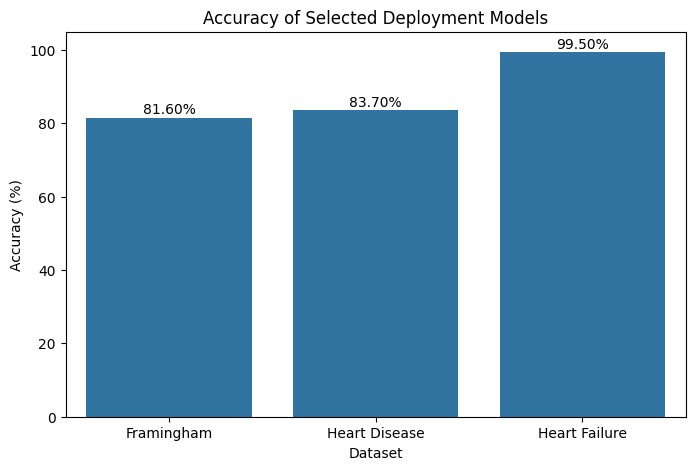

In [8]:
# ============================================================
# Accuracy Comparison
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=chart_data,
    x="Dataset",
    y="Accuracy"
)

plt.title("Accuracy of Selected Deployment Models")
plt.xlabel("Dataset")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)

for index, value in enumerate(chart_data["Accuracy"]):
    plt.text(
        index,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

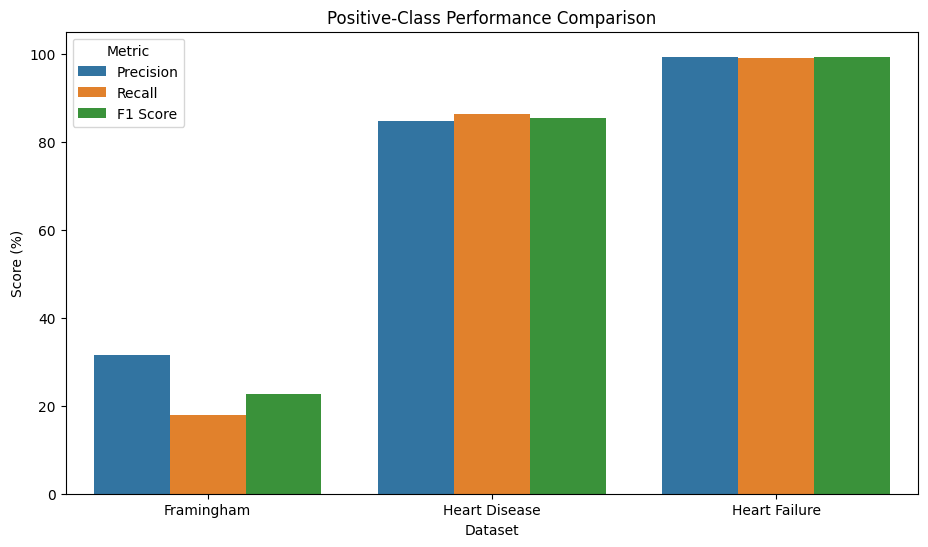

In [9]:
# ============================================================
# Precision, Recall and F1-Score Comparison
# ============================================================

metrics_long = chart_data.melt(
    id_vars="Dataset",
    value_vars=[
        "Precision",
        "Recall",
        "F1 Score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=metrics_long,
    x="Dataset",
    y="Score",
    hue="Metric"
)

plt.title("Positive-Class Performance Comparison")
plt.xlabel("Dataset")
plt.ylabel("Score (%)")
plt.ylim(0, 105)
plt.legend(title="Metric")

plt.show()

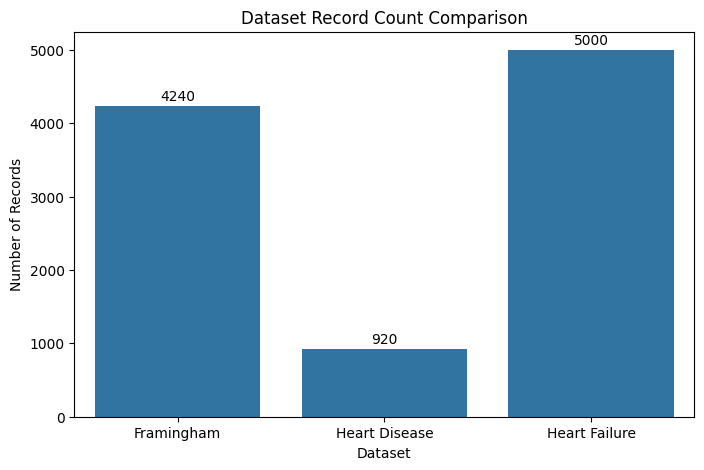

In [10]:
# ============================================================
# Dataset Size Comparison
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=dataset_comparison,
    x="Dataset",
    y="Records"
)

plt.title("Dataset Record Count Comparison")
plt.xlabel("Dataset")
plt.ylabel("Number of Records")

for index, value in enumerate(dataset_comparison["Records"]):
    plt.text(
        index,
        value + 80,
        str(value),
        ha="center"
    )

plt.show()

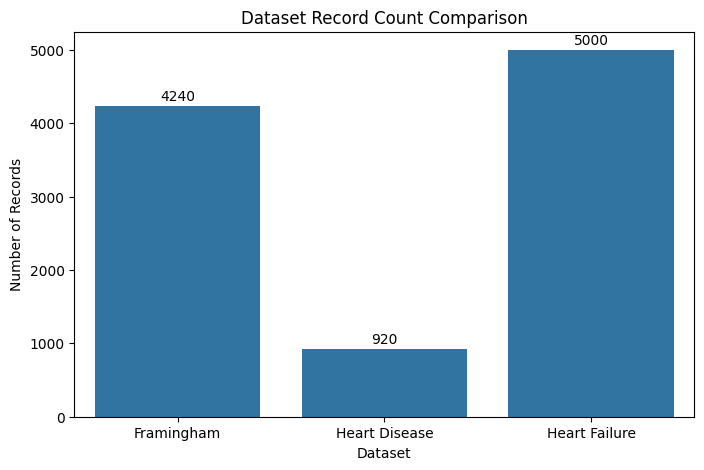

In [11]:
# ============================================================
# Dataset Size Comparison
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=dataset_comparison,
    x="Dataset",
    y="Records"
)

plt.title("Dataset Record Count Comparison")
plt.xlabel("Dataset")
plt.ylabel("Number of Records")

for index, value in enumerate(dataset_comparison["Records"]):
    plt.text(
        index,
        value + 80,
        str(value),
        ha="center"
    )

plt.show()

# 4. Comparative Interpretation

The three datasets were jointly analysed, but they were not merged into one training table because they use different target variables and represent different cardiovascular outcomes.

The Framingham dataset predicts ten-year coronary heart disease risk. The Heart Disease dataset predicts the presence of heart disease, while the Heart Failure dataset predicts an adverse outcome during the follow-up period.

The Framingham model achieved reasonable overall accuracy but relatively low positive-class recall and F1-score. This reflects the strong class imbalance in the dataset and shows that accuracy alone is not sufficient for evaluating medical classification models.

The Heart Disease XGBoost model produced a more balanced result across accuracy, precision, recall and F1-score. The Heart Failure XGBoost model achieved very high test performance. This result should be interpreted carefully because unusually high performance can indicate strong patterns in the data, repeated records or possible data leakage.

The final software therefore deploys three independent models through one Flask application rather than combining medically different target variables into one unclear prediction.

# 5. Integrated Application Design

The selected models were exported using Joblib and integrated into one Flask web application.

The platform contains three prediction modules:

- Framingham 10-Year CHD Risk Prediction
- Heart Disease Detection
- Heart Failure Outcome Prediction

The application also includes a comparison dashboard that presents dataset properties, model performance and visual summaries. This design supports joint analysis while preserving the separate clinical meaning of each prediction task.

# 6. Conclusion

This comparative notebook consolidated the findings from three independent cardiovascular machine learning experiments.

Each dataset followed a consistent workflow involving inspection, preprocessing, model training, evaluation and model selection. Random Forest was selected for the Framingham module, while XGBoost was selected for the Heart Disease and Heart Failure modules.

The project demonstrates how heterogeneous healthcare datasets can be compared and integrated at the application level without incorrectly merging different clinical targets into a single dataset. The resulting Flask platform provides one interface for three distinct cardiovascular prediction tasks.

The application and reported results are intended for academic demonstration only and are not suitable for clinical diagnosis.